# Day 7 | Lab 7.1: LangGraph Routing — Intelligent Customer Support Router

**Duration:** ~1.5 hours

**Scenario.** ShopSmart e-commerce — preserved from the source notebook. We build the **first lab in Spine A**, a customer-support router that classifies incoming queries and dispatches them to specialist handler nodes — the foundation Module 8 will grow into a full multi-agent system.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Build a LangGraph `StateGraph` with **conditional routing edges**.
2. Use **Pydantic structured output** with `with_structured_output(...)` for LLM-based classification.
3. Route customer queries to **specialist handler nodes** based on classifier output.
4. Visualize graph topology with **Mermaid diagrams** during development.
5. Compare the **StateGraph** API to the **Functional API** (`@entrypoint` / `@task`) and pick the right shape per use case.

**Tools.** LangGraph v1 · LangChain v1 · `langchain-openai` · `gpt-4.1-mini` (deterministic classification).

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


## 1. Install Dependencies

## 2. API Key Configuration

We load the OpenAI API key from environment variables (or a `.env` file via `python-dotenv`). No Colab `userdata` block — this lab targets a local Python venv.


In [ ]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install -q 'langchain>=1.0' 'langchain-core>=1.0' 'langgraph>=1.0' 'langchain-openai>=1.0' pydantic
%pip install langgraph -q

In [1]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv("..\\.env")
except ImportError:
    pass

for key in ['OPENAI_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


OPENAI_API_KEY: ✅ Loaded


In [2]:
# Verify the LangChain / LangGraph stack is installed
import langchain
import langgraph
print(f'langchain  : {langchain.__version__}')
# print(f'langgraph  : {langgraph.__version__}')

langchain  : 1.2.15


## 3. Core Imports

All imports needed for this lab are gathered here for clarity.

In [3]:
# Core imports
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display
import json

print("All imports successful")

All imports successful


## 4. Business Scenario: ShopSmart E-Commerce

**Company:** ShopSmart -- India's fastest-growing e-commerce platform
**Scale:** 50,000 customer support tickets per day

### The Problem

| Metric | Current | Industry Benchmark |
|--------|---------|-------------------|
| Misroute rate | 35% | <5% |
| Avg reassignments per ticket | 2.8 | <1.2 |
| CSAT score | 3.1/5.0 | 4.2/5.0 |
| First response time | 4.2 hours | <1 hour |

### The Solution

Build an intelligent routing system that:
1. **Classifies** each ticket by category (`order_status`, `returns`, `billing`, `product_info`)
2. **Assesses** priority (`low`, `medium`, `high`)
3. **Routes** to the correct specialist handler instantly

### Expected Impact

| Metric | Before | After |
|--------|--------|-------|
| Misroute rate | 35% | <5% |
| First response time | 4.2 hours | <15 minutes |
| CSAT score | 3.1 | 4.2+ |

### Architecture

```
Customer Query --> [Router Node] --> Conditional Edge --> [Handler Node] --> Response
                   (LLM classifies)                      (4 specialists)
```

## 5. Define the Graph State

In LangGraph, every graph operates on a **state** -- a shared data structure that flows through all nodes.

| Concept | Description |
|---------|-------------|
| State | A `TypedDict` that defines all data flowing through the graph |
| Node | A function that reads state and returns partial updates |
| Reducer | A function that merges updates into state (default: overwrite) |

Each node reads what it needs from the state and returns **only the fields it wants to update**. You do not need to return the entire state -- just the changed fields.

> **Important:** LangGraph's `StateGraph` supports `TypedDict` as the primary state schema. Pydantic state schemas are NOT supported for higher-level APIs like `create_agent`.

In [16]:
# Define the state schema for our customer support routing graph
class CustomerSupportState(TypedDict):
    """State for the customer support routing graph.

    This state flows through every node in the graph.
    Each node reads what it needs and returns partial updates.
    """
    customer_query: str       # The raw customer message
    customer_name: str        # Customer's name (for personalization)
    order_id: str             # Order ID if mentioned (extracted or empty)
    category: str             # Classified category: order_status, returns, billing, product_info
    priority: str             # Classified priority: low, medium, high
    response: str             # Final response to the customer
    confidence: float         # Router's confidence in classification (0.0 - 1.0)

print("CustomerSupportState defined with 7 fields")
print("Fields:", list(CustomerSupportState.__annotations__.keys()))

CustomerSupportState defined with 7 fields
Fields: ['customer_query', 'customer_name', 'order_id', 'category', 'priority', 'response', 'confidence']


## 6. Define the Routing Decision Schema (Pydantic)

We use **Pydantic structured output** to force the LLM to return a well-typed routing decision. This is more reliable than parsing free-text responses.

| Advantage | Description |
|-----------|-------------|
| Type safety | `Literal` types constrain the LLM to valid categories only |
| Field descriptions | Guide the LLM on what each field means |
| Automatic validation | Pydantic rejects invalid outputs |
| LangChain integration | `.with_structured_output()` handles the conversion |

The `with_structured_output()` method on `ChatOpenAI` accepts a Pydantic `BaseModel` and configures the LLM to return instances of that model directly -- no manual JSON parsing needed.

In [17]:
# Pydantic schema for structured routing decisions
class RouteDecision(BaseModel):
    """Structured routing decision from the LLM.

    The LLM must classify each customer query into exactly one category
    and assign a priority level. The confidence score indicates how
    certain the model is about its classification.
    """
    category: Literal["order_status", "returns", "billing", "product_info", "spam_query"] = Field(
        description=(
            "The primary category of the customer's query. "
            "order_status: tracking, delivery, shipping questions. "
            "returns: return requests, refund status, exchange inquiries. "
            "billing: payment issues, charges, invoices, pricing. "
            "product_info: product details, availability, specifications, recommendations."
            "spam_query: promotional, irrelevant, or suspicious content, not related any of the above."
        )
    )
    priority: Literal["low", "medium", "high"] = Field(
        description=(
            "Priority level based on urgency and impact. "
            "high: order not received, wrong item, payment failed, time-sensitive. "
            "medium: return request, billing discrepancy, delayed delivery. "
            "low: general inquiry, product questions, feature requests."
        )
    )
    confidence: float = Field(
        description="Confidence score between 0.0 and 1.0 for the classification.",
        ge=0.0, le=1.0
    )

# Show the schema
print("RouteDecision schema defined")
print(f"  Categories: {RouteDecision.model_fields['category'].annotation}")
print(f"  Priorities: {RouteDecision.model_fields['priority'].annotation}")
print(f"\nJSON Schema (excerpt):")
schema = RouteDecision.model_json_schema()
for field_name, field_info in schema.get("properties", {}).items():
    print(f"  {field_name}: {field_info.get('type', field_info.get('enum', 'N/A'))}")

RouteDecision schema defined
  Categories: typing.Literal['order_status', 'returns', 'billing', 'product_info', 'spam_query']
  Priorities: typing.Literal['low', 'medium', 'high']

JSON Schema (excerpt):
  category: string
  priority: string
  confidence: number


## 7. Initialize the LLM

We use two models in this lab:

| Model | Purpose | Temperature |
|-------|---------|-------------|
| `gpt-5-mini` | Routing classification (reasoning) | N/A (reasoning model) |
| `gpt-4.1-mini` | Response generation in handlers | 0.3 (controlled variety) |

**Important:** `gpt-5-mini` is a reasoning model -- it does **NOT** support the `temperature` parameter. If you need temperature control, use `gpt-4.1-mini` instead.

In [6]:
# Primary LLM for routing decisions (reasoning model -- no temperature parameter)
llm = ChatOpenAI(model="gpt-5-mini")

# Create a structured output version for routing
# This wraps the LLM to return RouteDecision objects directly
router_llm = llm.with_structured_output(RouteDecision)

# Secondary LLM for response generation (supports temperature)
response_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

print("LLMs initialized:")
print("  Router: gpt-5-mini (reasoning, structured output -> RouteDecision)")
print("  Response: gpt-4.1-mini (temperature=0.3)")

LLMs initialized:
  Router: gpt-5-mini (reasoning, structured output -> RouteDecision)
  Response: gpt-4.1-mini (temperature=0.3)


## 8. Build the Router Node

The router node is the **brain** of our system. It:

1. Takes the `customer_query` from state
2. Sends it to the LLM with classification instructions
3. Receives a structured `RouteDecision` back
4. Updates the state with `category`, `priority`, and `confidence`

This is a **deterministic workflow** -- the LLM decides the classification, but the routing paths are predefined by us. The router node is a plain Python function that:
- Accepts the full state as input
- Returns a dictionary with only the fields to update

In [18]:
def router_node(state: CustomerSupportState) -> dict:
    """Classify the customer query into a category and priority.

    Uses Pydantic structured output to ensure the LLM returns
    a valid RouteDecision with category, priority, and confidence.
    """
    query = state["customer_query"]
    customer_name = state.get("customer_name", "Customer")

    # Build the classification prompt
    prompt = f"""You are ShopSmart's intelligent support router. Analyze this customer query
and classify it accurately.

Customer: {customer_name}
Query: {query}

Classify into exactly ONE category and assign a priority level.
Consider the urgency, emotional tone, and specific request type."""

    # Get structured routing decision from LLM
    decision = router_llm.invoke(prompt)

    print(f"  Router Decision: category={decision.category}, "
          f"priority={decision.priority}, confidence={decision.confidence:.2f}")

    # Return partial state update -- only the fields we want to change
    return {
        "category": decision.category,
        "priority": decision.priority,
        "confidence": decision.confidence
    }

print("router_node defined -- classifies queries using gpt-5-mini + structured output")

router_node defined -- classifies queries using gpt-5-mini + structured output


## 9. Build the Specialist Handler Nodes

Each handler node generates a **domain-specific response**. In a production system, these would:
- Query databases for real-time data (order tracking, inventory)
- Use RAG to retrieve relevant policies and documentation
- Call external APIs (shipping trackers, payment gateways)

For this lab, we simulate with **synthetic data** (inline databases) and **LLM-generated responses** enriched with mock data lookups.

| Handler | Category | What It Does |
|---------|----------|-------------|
| `handle_order_status` | `order_status` | Looks up order in database, returns tracking info |
| `handle_returns` | `returns` | Checks return eligibility, provides return instructions |
| `handle_billing` | `billing` | Addresses payment issues, invoice queries |
| `handle_product_info` | `product_info` | Looks up product details, availability, specs |

In [20]:
# ===== Synthetic Data: Order Database =====
ORDERS_DB = {
    "ORD-1001": {
        "customer": "Priya Sharma",
        "product": "Samsung Galaxy S24 Ultra",
        "status": "In Transit",
        "tracking_id": "DTDC-98712345",
        "expected_delivery": "2026-04-12",
        "order_date": "2026-04-02",
        "amount": 74999
    },
    "ORD-1002": {
        "customer": "Rahul Verma",
        "product": "Sony WH-1000XM5 Headphones",
        "status": "Delivered",
        "tracking_id": "BLUEDART-44556677",
        "expected_delivery": "2026-04-05",
        "order_date": "2026-03-30",
        "amount": 24990
    },
    "ORD-1003": {
        "customer": "Ananya Reddy",
        "product": "Apple MacBook Air M3",
        "status": "Processing",
        "tracking_id": None,
        "expected_delivery": "2026-04-18",
        "order_date": "2026-04-07",
        "amount": 114900
    },
    "ORD-1004": {
        "customer": "Vikram Patel",
        "product": "Nike Air Max 270",
        "status": "Delivered",
        "tracking_id": "ECOM-EXPRESS-77889900",
        "expected_delivery": "2026-04-01",
        "order_date": "2026-03-25",
        "amount": 12995
    },
    "ORD-1005": {
        "customer": "Meera Iyer",
        "product": "Kindle Paperwhite (2025)",
        "status": "Return Requested",
        "tracking_id": "DELHIVERY-11223344",
        "expected_delivery": "2026-03-28",
        "order_date": "2026-03-20",
        "amount": 16999
    }
}

# ===== Synthetic Data: Product Database =====
PRODUCTS_DB = {
    "samsung-s24-ultra": {
        "name": "Samsung Galaxy S24 Ultra",
        "price": 74999,
        "category": "Smartphones",
        "in_stock": True,
        "rating": 4.6,
        "specs": "6.8-inch AMOLED, Snapdragon 8 Gen 3, 200MP Camera, 5000mAh"
    },
    "sony-wh1000xm5": {
        "name": "Sony WH-1000XM5 Headphones",
        "price": 24990,
        "category": "Audio",
        "in_stock": True,
        "rating": 4.7,
        "specs": "Industry-leading ANC, 30-hour battery, LDAC, Multipoint"
    },
    "macbook-air-m3": {
        "name": "Apple MacBook Air M3",
        "price": 114900,
        "category": "Laptops",
        "in_stock": False,
        "rating": 4.8,
        "specs": "M3 chip, 16GB RAM, 256GB SSD, 18-hour battery, Liquid Retina"
    },
    "nike-air-max-270": {
        "name": "Nike Air Max 270",
        "price": 12995,
        "category": "Footwear",
        "in_stock": True,
        "rating": 4.4,
        "specs": "Air cushioning, mesh upper, rubber outsole, multiple colors"
    },
    "kindle-paperwhite-2025": {
        "name": "Kindle Paperwhite (2025)",
        "price": 16999,
        "category": "E-Readers",
        "in_stock": True,
        "rating": 4.5,
        "specs": "6.8-inch display, 300 ppi, waterproof, 16GB, USB-C"
    }
}

print(f"Orders DB: {len(ORDERS_DB)} orders loaded")
print(f"Products DB: {len(PRODUCTS_DB)} products loaded")

Orders DB: 5 orders loaded
Products DB: 5 products loaded


In [21]:
# ===== Handler 1: Order Status =====
def handle_order_status(state: CustomerSupportState) -> dict:
    """Handle order tracking and delivery queries.
    Looks up the order in ORDERS_DB and generates a response
    enriched with real tracking data.
    """
    query = state["customer_query"]
    order_id = state.get("order_id", "")
    customer_name = state.get("customer_name", "Customer")

    # Try to find order in database
    order_info = ORDERS_DB.get(order_id, None)

    if order_info:
        context = (
            f"Order {order_id}: {order_info['product']}, "
            f"Status: {order_info['status']}, "
            f"Tracking: {order_info['tracking_id'] or 'Not yet assigned'}, "
            f"Expected delivery: {order_info['expected_delivery']}"
        )
    else:
        context = "Order not found in database. Ask customer to verify their order ID."

    prompt = f"""You are ShopSmart's order tracking specialist. Help the customer with their query.

Customer: {customer_name}
Query: {query}
Order Data: {context}

Provide a helpful, empathetic response. Include specific tracking details if available.
Keep the response concise (2-3 sentences). Use INR for currency."""

    response = response_llm.invoke(prompt)
    print(f"  [Order Status Handler] Generated response for {customer_name}")
    return {"response": response.content}


# ===== Handler 2: Returns =====
def handle_returns(state: CustomerSupportState) -> dict:
    """Handle return requests, refund status, and exchange inquiries.
    Checks return eligibility (30-day window) and generates
    appropriate return instructions.
    """
    query = state["customer_query"]
    order_id = state.get("order_id", "")
    customer_name = state.get("customer_name", "Customer")

    order_info = ORDERS_DB.get(order_id, None)

    if order_info:
        context = (
            f"Order {order_id}: {order_info['product']}, "
            f"Amount: INR {order_info['amount']:,}, "
            f"Order date: {order_info['order_date']}, "
            f"Status: {order_info['status']}. "
            f"ShopSmart return policy: 30-day return window from delivery. "
            f"Refund within 5-7 business days after pickup."
        )
    else:
        context = "Order not found. ShopSmart's general return policy: 30-day window from delivery."

    prompt = f"""You are ShopSmart's returns specialist. Help the customer with their return/refund query.

Customer: {customer_name}
Query: {query}
Order & Policy: {context}

Provide clear return instructions. Be empathetic and solution-oriented.
Keep the response concise (2-3 sentences)."""

    response = response_llm.invoke(prompt)
    print(f"  [Returns Handler] Generated response for {customer_name}")
    return {"response": response.content}


# ===== Handler 3: Billing =====
def handle_billing(state: CustomerSupportState) -> dict:
    """Handle payment issues, charges, invoices, and pricing queries."""
    query = state["customer_query"]
    customer_name = state.get("customer_name", "Customer")
    order_id = state.get("order_id", "")

    order_info = ORDERS_DB.get(order_id, None)
    if order_info:
        context = (
            f"Order {order_id}: {order_info['product']}, "
            f"Amount: INR {order_info['amount']:,}, "
            f"Order date: {order_info['order_date']}"
        )
    else:
        context = "No specific order referenced."

    prompt = f"""You are ShopSmart's billing specialist. Help the customer with their payment/billing query.

Customer: {customer_name}
Query: {query}
Billing Data: {context}

ShopSmart accepts UPI, credit/debit cards, net banking, and EMI options.
Refunds are processed within 5-7 business days to the original payment method.
Keep the response concise (2-3 sentences)."""

    response = response_llm.invoke(prompt)
    print(f"  [Billing Handler] Generated response for {customer_name}")
    return {"response": response.content}


# ===== Handler 4: Product Info =====
def handle_product_info(state: CustomerSupportState) -> dict:
    """Handle product details, availability, specifications, and recommendations."""
    query = state["customer_query"]
    customer_name = state.get("customer_name", "Customer")

    # Search products database for relevant products
    matching_products = []
    query_lower = query.lower()
    for pid, pinfo in PRODUCTS_DB.items():
        if any(word in query_lower for word in pinfo["name"].lower().split()):
            matching_products.append(pinfo)

    if matching_products:
        context = "\n".join([
            f"- {p['name']}: INR {p['price']:,}, "
            f"{'In Stock' if p['in_stock'] else 'Out of Stock'}, "
            f"Rating: {p['rating']}/5, Specs: {p['specs']}"
            for p in matching_products
        ])
    else:
        context = "No exact product match found. Provide general assistance."

    prompt = f"""You are ShopSmart's product specialist. Help the customer with their product query.

Customer: {customer_name}
Query: {query}
Product Data:
{context}

Provide helpful product information. Include price, availability, and key specs.
Keep the response concise (2-3 sentences). Use INR for currency."""

    response = response_llm.invoke(prompt)
    print(f"  [Product Info Handler] Generated response for {customer_name}")
    return {"response": response.content}


print("All 4 handler nodes defined:")
print("  1. handle_order_status -- order tracking, delivery queries")
print("  2. handle_returns      -- return/refund/exchange queries")
print("  3. handle_billing      -- payment, charges, invoice queries")
print("  4. handle_product_info -- product details, availability, specs")

All 4 handler nodes defined:
  1. handle_order_status -- order tracking, delivery queries
  2. handle_returns      -- return/refund/exchange queries
  3. handle_billing      -- payment, charges, invoice queries
  4. handle_product_info -- product details, availability, specs


## 10. Define the Routing Function

The routing function is the **conditional edge** logic. It reads the classified `category` from state and returns the name of the next node to execute.

This is **pure Python** -- no LLM involved. The LLM already made its decision in the router node; now we just follow the predetermined path.

```
State["category"] == "order_status"  -->  "handle_order_status"
State["category"] == "returns"       -->  "handle_returns"
State["category"] == "billing"       -->  "handle_billing"
State["category"] == "product_info"  -->  "handle_product_info"
```

In [22]:
def route_by_category(state: CustomerSupportState) -> str:
    """Route to the appropriate handler based on classified category.

    Returns the name of the next node to execute.
    This is a deterministic routing function -- no LLM needed here.
    The LLM already classified the query in the router node.
    """
    category = state["category"]

    route_map = {
        "order_status": "handle_order_status",
        "returns": "handle_returns",
        "billing": "handle_billing",
        "product_info": "handle_product_info",
        "spam_query": "end"
    }

    destination = route_map.get(category, "handle_product_info")  # Default fallback
    print(f"  Routing to: {destination}")
    return destination

print("route_by_category defined -- maps category string to handler node name")

route_by_category defined -- maps category string to handler node name


## 11. Build and Compile the StateGraph

Now we assemble all the pieces into a LangGraph `StateGraph`:

1. **Add nodes** -- router + 4 handlers
2. **Add edges** -- `START` to router, then conditional edges to handlers, handlers to `END`
3. **Compile** -- produces an executable graph with optional checkpointing

The `add_conditional_edges()` method is the key LangGraph feature for routing patterns. It accepts:

| Parameter | Description |
|-----------|-------------|
| Source node | The node after which routing occurs |
| Routing function | A Python function that returns the destination node name |
| Mapping dict | Maps routing function return values to node names |

In [23]:
# Build the graph
builder = StateGraph(CustomerSupportState)

# Add all nodes
builder.add_node("router", router_node)
builder.add_node("handle_order_status", handle_order_status)
builder.add_node("handle_returns", handle_returns)
builder.add_node("handle_billing", handle_billing)
builder.add_node("handle_product_info", handle_product_info)

# Add edges
builder.add_edge(START, "router")  # Entry point: always go to router first

# Conditional routing: router -> appropriate handler
builder.add_conditional_edges(
    "router",                       # Source node
    route_by_category,              # Routing function
    {                               # Destination mapping
        "handle_order_status": "handle_order_status",
        "handle_returns": "handle_returns",
        "handle_billing": "handle_billing",
        "handle_product_info": "handle_product_info",
        "end": END
    }
)

# All handlers go to END
builder.add_edge("handle_order_status", END)
builder.add_edge("handle_returns", END)
builder.add_edge("handle_billing", END)
builder.add_edge("handle_product_info", END)

# Compile with in-memory checkpointer (dev-only; use PostgresSaver in production)
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled successfully!")
print(f"Nodes: {list(graph.get_graph().nodes.keys())}")

Graph compiled successfully!
Nodes: ['__start__', 'router', 'handle_order_status', 'handle_returns', 'handle_billing', 'handle_product_info', '__end__']


## 12. Visualize the Graph

LangGraph can generate **Mermaid diagrams** of your graph topology. This is invaluable for:

- Debugging routing logic
- Documentation for stakeholders
- Verifying edge connections are correct
- Understanding the flow before running queries

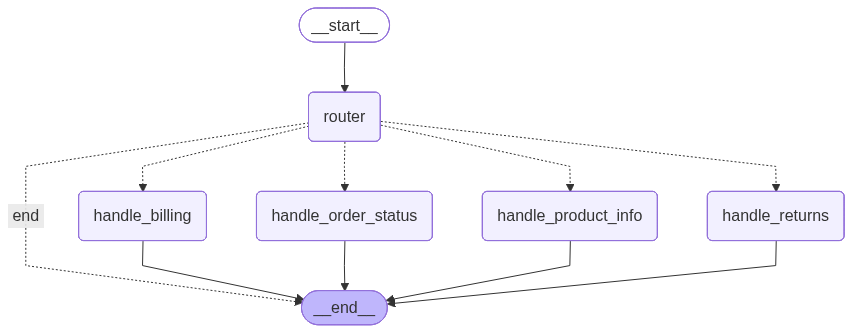

In [24]:
# Display the graph as a Mermaid diagram
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text if PNG rendering fails
    print("Mermaid diagram (paste into https://mermaid.live to view):")
    print(graph.get_graph().draw_mermaid())

## 13. Test with 5 Diverse Customer Queries

Let's test our routing system with queries that should trigger different routes:

| # | Query Theme | Expected Category | Expected Priority |
|---|------------|-------------------|-------------------|
| 1 | Order tracking (urgent) | `order_status` | medium/high |
| 2 | Return request | `returns` | medium |
| 3 | Double billing charge | `billing` | high |
| 4 | Product availability | `product_info` | low |
| 5 | Defective product (ambiguous: return or product?) | `returns` | high |

In [ ]:
# Define 5 diverse test queries
test_queries = [
    {
        "customer_query": "What is linked list in Python, how to implement it? Explain me with example code",
        "customer_name": "Priya Sharma",
        "order_id": "ORD-1001",
        "expected_category": "spam_query"
    },
    {
        "customer_query": "Where is my order ORD-1001? It has been 6 days and I still have not received my Samsung phone. This is urgent!",
        "customer_name": "Priya Sharma",
        "order_id": "ORD-1001",
        "expected_category": "order_status"
    },
    {
        "customer_query": "I want to return the headphones I bought last week. Order ORD-1002. They do not fit well and I want a full refund.",
        "customer_name": "Rahul Verma",
        "order_id": "ORD-1002",
        "expected_category": "returns"
    },
    {
        "customer_query": "I was charged twice for my Nike shoes order ORD-1004! INR 12,995 was deducted two times from my account. Fix this immediately!",
        "customer_name": "Vikram Patel",
        "order_id": "ORD-1004",
        "expected_category": "billing"
    },
    {
        "customer_query": "Can you tell me the specs and price of the MacBook Air M3? Also is it currently in stock?",
        "customer_name": "Deepak Kumar",
        "order_id": "",
        "expected_category": "product_info"
    },
    {
        "customer_query": "I need help with my Kindle Paperwhite order ORD-1005. The screen has a dead pixel and I either want a replacement or my money back.",
        "customer_name": "Meera Iyer",
        "order_id": "ORD-1005",
        "expected_category": "returns"
    }
]

# Run each test query through the graph
results = []
for i, test in enumerate(test_queries[:2], 1):
    print(f"\n{'='*70}")
    print(f"TEST {i}: {test['customer_name']}")
    print(f"Query: {test['customer_query'][:80]}...")
    print(f"Expected: {test['expected_category']}")
    print("-" * 70)

    # Prepare input state (only fields relevant as input)
    input_state = {
        "customer_query": test["customer_query"],
        "customer_name": test["customer_name"],
        "order_id": test["order_id"],
        "category": "",
        "priority": "",
        "response": "",
        "confidence": 0.0
    }

    # Each query gets a unique thread_id for the checkpointer
    config = {"configurable": {"thread_id": f"test-{i}"}}

    # Invoke the graph
    result = graph.invoke(input_state, config)

    # Store result for analysis
    results.append({
        "query_num": i,
        "customer": test["customer_name"],
        "expected": test["expected_category"],
        "actual": result["category"],
        "priority": result["priority"],
        "confidence": result["confidence"],
        "response": result["response"],
        "correct": test["expected_category"] == result["category"]
    })

    print(f"\n  Category: {result['category']} | Priority: {result['priority']} | "
          f"Confidence: {result['confidence']:.2f}")
    print(f"  Response: {result['response'][:150]}...")

print(f"\n{'='*70}")
print("All 5 test queries processed!")


TEST 1: Priya Sharma
Query: What is linked list in Python, how to implement it? Explain me with example code...
Expected: order_status
----------------------------------------------------------------------
  Router Decision: category=product_info, priority=low, confidence=0.42
  Routing to: handle_product_info
  [Product Info Handler] Generated response for Priya Sharma

  Category: product_info | Priority: low | Confidence: 0.42
  Response: Hello Priya! A linked list in Python is a data structure where each element (node) contains data and a reference to the next node, allowing efficient ...

TEST 2: Priya Sharma
Query: Where is my order ORD-1001? It has been 6 days and I still have not received my ...
Expected: order_status
----------------------------------------------------------------------
  Router Decision: category=order_status, priority=high, confidence=0.96
  Routing to: handle_order_status
  [Order Status Handler] Generated response for Priya Sharma

  Category: order_statu

## 14. Routing Analysis

Let's analyze how our router performed across all test queries -- accuracy, confidence distribution, and category/priority breakdown.

In [15]:
# Build summary table
print(f"{'#':<4} {'Customer':<18} {'Expected':<16} {'Actual':<16} {'Priority':<10} {'Conf':<8} {'Match'}")
print("-" * 90)

correct_count = 0
total_confidence = 0.0

for r in results:
    match_str = "PASS" if r["correct"] else "FAIL"
    print(f"{r['query_num']:<4} {r['customer']:<18} {r['expected']:<16} {r['actual']:<16} "
          f"{r['priority']:<10} {r['confidence']:<8.2f} {match_str}")
    if r["correct"]:
        correct_count += 1
    total_confidence += r["confidence"]

print("-" * 90)
accuracy = correct_count / len(results) * 100
avg_confidence = total_confidence / len(results)

print(f"\nRouting Accuracy: {correct_count}/{len(results)} ({accuracy:.0f}%)")
print(f"Average Confidence: {avg_confidence:.2f}")

# Priority distribution
from collections import Counter
priority_counts = Counter(r["priority"] for r in results)
print(f"\nPriority Distribution:")
for priority, count in sorted(priority_counts.items()):
    print(f"  {priority}: {count} queries")

# Category distribution
category_counts = Counter(r["actual"] for r in results)
print(f"\nCategory Distribution:")
for category, count in sorted(category_counts.items()):
    print(f"  {category}: {count} queries")

#    Customer           Expected         Actual           Priority   Conf     Match
------------------------------------------------------------------------------------------
1    Priya Sharma       order_status     order_status     high       0.95     PASS
2    Rahul Verma        returns          returns          medium     0.97     PASS
3    Vikram Patel       billing          billing          high       0.97     PASS
4    Deepak Kumar       product_info     product_info     low        0.97     PASS
5    Meera Iyer         returns          returns          high       0.98     PASS
------------------------------------------------------------------------------------------

Routing Accuracy: 5/5 (100%)
Average Confidence: 0.97

Priority Distribution:
  high: 3 queries
  low: 1 queries
  medium: 1 queries

Category Distribution:
  billing: 1 queries
  order_status: 1 queries
  product_info: 1 queries
  returns: 2 queries


---
## 15. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **`StateGraph` vs LCEL chain** | Reach for StateGraph when state must persist across nodes, when conditional routing depends on intermediate results, or when you need checkpointing/HITL |
| **TypedDict state + reducers** | TypedDict is lightweight and merges fields; `Annotated[..., add_messages]` lets you append rather than overwrite |
| **Conditional edges** | `add_conditional_edges(node, router_fn, mapping)` — the router_fn returns a string that picks the next node |
| **Structured output for routing** | `llm.with_structured_output(RoutingDecision)` removes regex-parsing brittleness and gives typed dispatch |
| **Mermaid visualization** | `graph.get_graph().draw_mermaid_png()` — invaluable when the topology gets non-trivial; print it during development |
| **Functional API alternative** | `@entrypoint` + `@task` is closer to plain Python; StateGraph wins when you need typed state, conditional edges, or LangGraph Studio |

**Next Lab:** Lab 7.2 — Parallelization: Fan-Out / Fan-In with Send API ⚡


## 16. Stretch Exercise (Optional)

1. Add a **logging callback** that fires after every node — capture `node_name`, `input_state_keys`, `output_state_keys`, `latency_ms` to a list. (Hint: subclass `BaseCallbackHandler` or use `astream_events`.)
2. Add a 6th specialist for **billing disputes** — new Pydantic enum value, new node, new mapping entry. How many lines does it take? (Answer: ~10. That's why StateGraph wins for evolving systems.)
3. Add a **fallback node** for low-confidence classifications: if `routing.confidence < 0.65`, route to a `human_handoff` node that returns a polite escalation message.
4. Convert the `route_by_category` function into a **two-stage router**: first pick category, then pick priority (HIGH/NORMAL/LOW). Use a single LLM call with a nested Pydantic model.
5. Build a 50-query eval set and measure routing accuracy across 3 LLMs (Haiku 4.5 vs `gpt-4.1-mini` vs Llama 3.3 70B on Groq). Track tokens-per-routing-call.


---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. When do you need a LangGraph `StateGraph` instead of an LCEL chain?**

*Hint:* Three things LCEL can't easily express.

*Answer sketch:* Reach for StateGraph when (a) you need **state persistence across nodes** that mutate over multiple super-steps, (b) you need **conditional routing that depends on intermediate state**, or (c) you need **checkpointing / HITL / time-travel**. LCEL is excellent for fixed, branchless pipelines — it's a graph of Runnables, but the *runtime* doesn't model state. StateGraph adds an explicit state object, conditional edges, and a checkpointer.

---

**Q2. What does a `TypedDict` state give you that a Pydantic model doesn't (in LangGraph)?**

*Hint:* Reducers and partial updates.

*Answer sketch:* TypedDict is the **default** because LangGraph natively merges dict updates from each node — a node returns a partial dict and the framework applies the reducers (e.g., `add_messages` appends to a list rather than overwriting). Pydantic models work too (set `state_schema=MyModel`), but you get strict validation and slightly less flexibility around partial updates. TypedDict is the LangGraph idiom.

---

**Q3. Conditional edges vs branching in LCEL — what's the real difference?**

*Hint:* State machine vs functional dispatch.

*Answer sketch:* LCEL's `RunnableBranch` picks one branch on the *input* and runs that pipeline to completion — no shared state, no return-to-router. `add_conditional_edges` in LangGraph lets a router function look at the *current state* and route to one of N next nodes, which then update state and may route again — it's a true state machine with cycles allowed. LCEL is a DAG; LangGraph is a graph (can have loops).

---

**Q4. What are reducers (e.g., `add_messages`) and why do they exist?**

*Hint:* Combining concurrent updates safely.

*Answer sketch:* A reducer is the function that merges a node's partial-state output into the running state. The default reducer is `dict.update` (overwrite). `add_messages` appends new messages to the existing message list (and dedups by ID) — exactly what you need for chat history. They exist because (a) `Send`/parallel branches produce concurrent updates that must be merged deterministically, and (b) chat messages should accumulate, not overwrite.

---

**Q5. When use the Functional API (`@entrypoint`/`@task`) vs `StateGraph`?**

*Hint:* Imperative Python vs declarative graph.

*Answer sketch:* Functional API (`@entrypoint`, `@task`) reads like normal async Python — you call tasks in a function body, await results, and the framework handles checkpointing transparently. Use it when the flow is mostly linear with a few branches, and you want minimal boilerplate. Use `StateGraph` when topology is complex (many nodes, conditional edges, parallel fan-out), when you want **graph visualization**, or when you need fine-grained control over edges and reducers.

---

**Q6. How does graph visualization (`draw_mermaid_png`) help during development?**

*Hint:* Catches dead nodes and missing edges before runtime.

*Answer sketch:* Mermaid output makes the topology visible — orphan nodes, missing return edges to `END`, accidental cycles, and disconnected sub-paths all show up immediately. It also doubles as documentation: you can paste the diagram into a design doc or PR description. In a multi-agent or routing graph with 5+ nodes, the mental model is much sharper when you can see it.

---

**Q7. What's the difference between `START`, `END`, and a regular node?**

*Hint:* Sentinels vs functions.

*Answer sketch:* `START` and `END` are **sentinel constants** — they mark graph entry and exit. They aren't functions and don't execute. A regular node is a callable that takes the state, returns a partial-state dict, and is connected by edges. You always have `add_edge(START, first_node)` and at least one path that reaches `END`. (LangGraph also auto-terminates on `Command(goto=END)`.)

---

**Q8. How would you add a logging step that runs after every node?**

*Hint:* Callbacks beat hand-wired logging nodes.

*Answer sketch:* Two clean options: (a) use a `BaseCallbackHandler` subclass with `on_chain_end` and pass it via `RunnableConfig.callbacks` — fires for every Runnable including each node; (b) consume `graph.astream_events(...)` and emit a log line per `on_chain_end` event. Avoid wrapping every node in a logging shim — that pollutes the graph topology and breaks reusability.

